How can we check if our model is overfitting on the dataset ? What about outliers, are they affecting our model's performance ?


# **Given information about placement data of a batch of students in college campus, predict whether the student will be placed or not.**

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!wget https://raw.githubusercontent.com/amm-ik/ml-datasets/main/module-1/placementData.csv

--2026-03-27 21:37:55--  https://raw.githubusercontent.com/amm-ik/ml-datasets/main/module-1/placementData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19712 (19K) [text/plain]
Saving to: ‘placementData.csv’

placementData.csv   100%[===================>]  19.25K  --.-KB/s    in 0s      

2026-03-27 21:37:55 (92.5 MB/s) - ‘placementData.csv’ saved [19712/19712]



Read the file and Observe

In [3]:
df = pd.read_csv("placementData.csv")
df.head(20)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.00,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.00,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed,425000.0
5,6,M,55.00,Others,49.80,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,NaN
6,7,F,46.00,Others,49.20,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,NaN
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.00,Mkt&Fin,62.14,Placed,252000.0
8,9,M,73.00,Central,79.00,Central,Commerce,72.00,Comm&Mgmt,No,91.34,Mkt&Fin,61.29,Placed,231000.0
9,10,M,58.00,Central,70.00,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,NaN


In [4]:
df['degree_t'].unique()
# df['hsc_s'].unique()

array(['Sci&Tech', 'Comm&Mgmt', 'Others'], dtype=object)

Let's try to explore these features - Both categorical and numerical.
Check For -
1. Data types of each features
2. Missing Values
3. Unique Values
4. Encode categorical features  

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [6]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


Drop columns that are of no use. In our case, we have no use of sl_no

In [7]:
df = df.drop(['sl_no'], axis=1)

Can we obtain some insights on the dataset using -
1. Categorical Plots such as (not limited to)

  *   Gender comparison - *(Discussed below)*
  *   Influence of any specialization/school courses in Job
  *   Placement statistics with respect to various features

2. Correlation Matrix/ Heat maps between features

<Axes: xlabel='status', ylabel='count'>

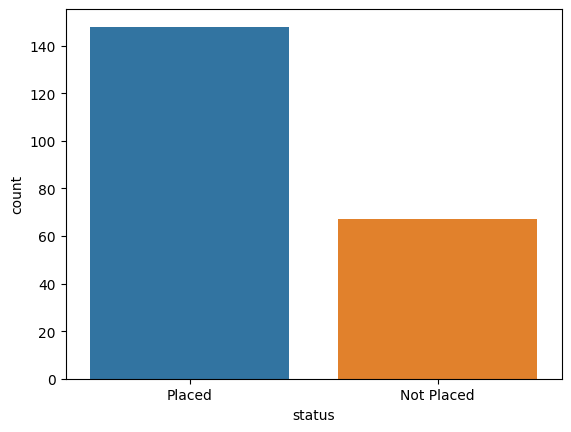

In [8]:
sns.countplot(df, x='status', hue='status')

<Axes: xlabel='status', ylabel='count'>

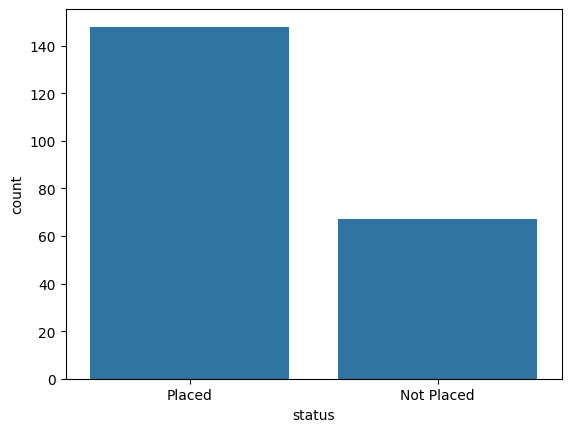

In [9]:
sns.countplot(x='status', data=df)

In [10]:
distribution_df = pd.DataFrame(df.groupby(['gender','status'])['status'].count())
print(distribution_df)

                   status
gender status            
F      Not Placed      28
       Placed          48
M      Not Placed      39
       Placed         100


<Axes: xlabel='gender', ylabel='count'>

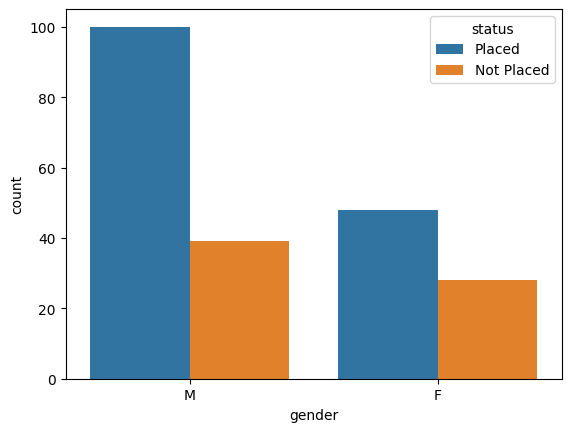

In [11]:
sns.countplot(x='gender', hue='status', data=df)
# Plotting placement stats by gender

Text(30.519367283950622, 0.5, 'Degree')

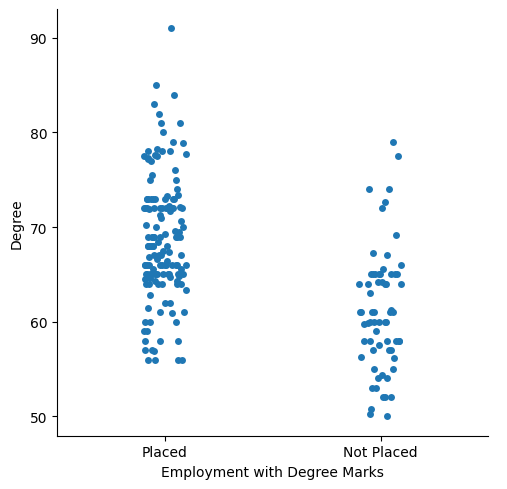

In [12]:
# Plotting Placement stats by degree percentage
sns.catplot(y='degree_p', x='status', data=df)
plt.xlabel('Employment with Degree Marks')
plt.ylabel('Degree')

Can you find some more interesting insights through this dataset ?

In [13]:
# placement based on area of study
distribution_df = pd.DataFrame(df.groupby(['hsc_s','status'])['status'].count())
print(distribution_df)

                     status
hsc_s    status            
Arts     Not Placed       5
         Placed           6
Commerce Not Placed      34
         Placed          79
Science  Not Placed      28
         Placed          63


<Axes: xlabel='hsc_s', ylabel='count'>

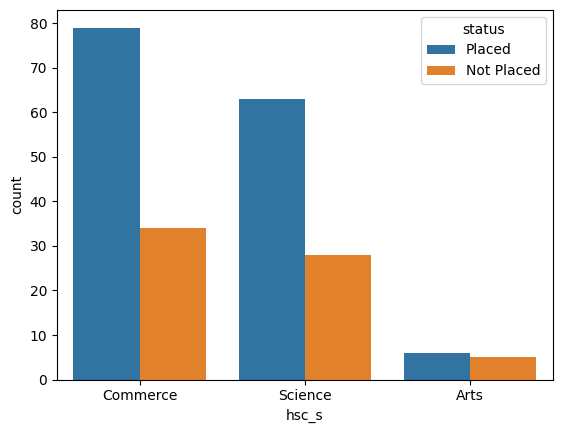

In [14]:
sns.countplot(x='hsc_s', hue='status', data=df)

**REMINDER**

Do we need any more preprocessing step ? Check if you have -

1.   Encoded all the categorical features
2.   Collinearity Test
3.   Normalisation/Standardization of features
4.   Handled all missing values, noisy inputs.





<Axes: >

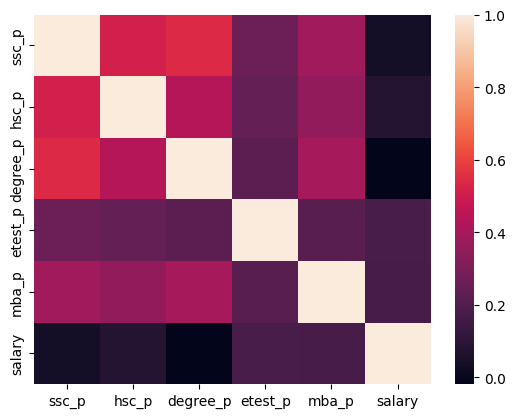

In [15]:
numeric_df = df.select_dtypes(include=[float, int])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)

In [16]:
# 1 / (1 - R^2)

def multicollinearity_by_vif(X, vif=5):
    """Remove columns from X whose VIF is greater than supplied 'vif'
    Parameters:
        X:array or dataframe containing data excluding target variable
        vif: int or float of limiting value of VIF
    Note:
        This function changes X inplace
    """
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    for i in range(len(X.columns)):
        # Ensure there are at least two columns left
        if X.shape[1] < 2:
            print("Not enough columns left to calculate VIF. Exiting.")
            break

        # View which columns are left
        print(f"Columns remaining at iteration {i}: {X.columns}")

        # Calculate VIF
        vif_data = pd.Series(
            [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
            index=X.columns
        ).sort_values(ascending=False)

        # If VIF is above our threshold, eliminate the column with the highest VIF
        if vif_data.iloc[0] > vif:
            print(f"Removed: {vif_data.index[0]}, VIF: {vif_data.iloc[0]}")
            X.drop(vif_data.index[0], axis=1, inplace=True)
        else:
            break

multicollinearity_by_vif(X=df.drop(['ssc_p', 'ssc_b', 'hsc_p', 'mba_p', 'workex', 'hsc_s', 'gender', 'hsc_b', 'specialisation', 'degree_t', 'status', 'salary'], axis=1))

Columns remaining at iteration 0: Index(['degree_p', 'etest_p'], dtype='object')
Removed: degree_p, VIF: 28.089688207619993
Not enough columns left to calculate VIF. Exiting.


In [17]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


OK, let's split our dataset into train-dev-test  

In [18]:
from sklearn.model_selection import train_test_split

# Drop 'salary' as it's an outcome and has NaN values for 'Not Placed' students
df_processed = df.drop(['salary'], axis=1)

# Separate features (X) and target (y)
X = df_processed.drop('status', axis=1)
y = df_processed['status']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split data into training and temporary (dev + test) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split temporary set into development and test sets
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Development set shape: {X_dev.shape}, {y_dev.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")


Training set shape: (150, 14), (150,)
Development set shape: (32, 14), (32,)
Test set shape: (33, 14), (33,)


Import your classification model of choice, fit the model on training set

In [22]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for smaller datasets and for binary classification

# Fit the model to the training data
model.fit(X_train, y_train)

print("Model fitted successfully!")

Model fitted successfully!


Let's try to measure performance using -
1. Confusion Matrix
2. Accuracy
3. Precision
4. Recall
5. ROC Curve
6. AUC to Compare the performance of classification algorithms used
7. Precision Recall Curve  

Confusion Matrix:
[[ 3  7]
 [ 3 19]]


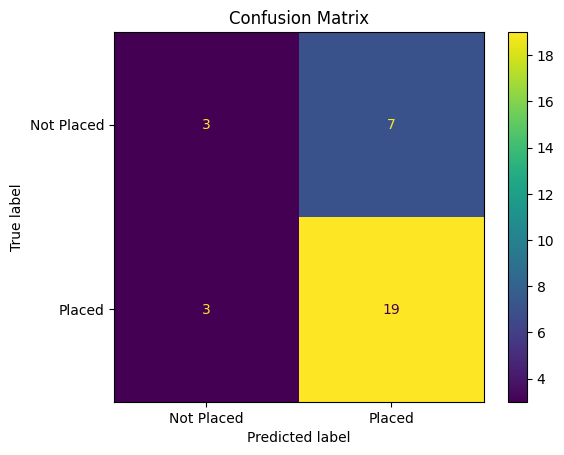


Accuracy: 0.6875
Precision: 0.7308
Recall: 0.8636


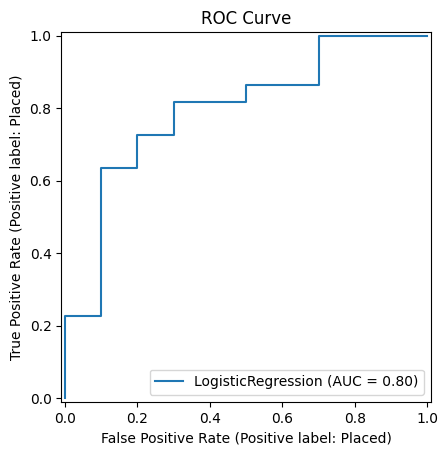

AUC: 0.7955


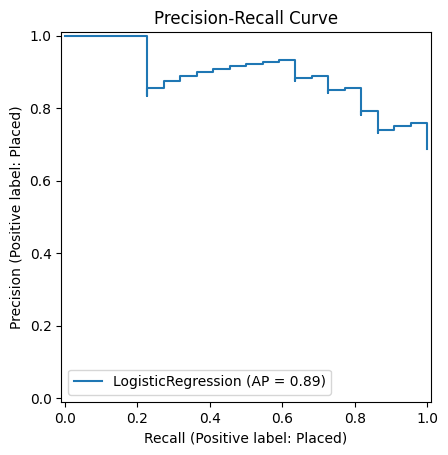

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Make predictions on the development set
y_pred = model.predict(X_dev)
y_pred_proba = model.predict_proba(X_dev)[:, 1] # Probability of the positive class (Placed)

# 1. Confusion Matrix
cm = confusion_matrix(y_dev, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# 2. Accuracy
accuracy = accuracy_score(y_dev, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Precision
# For binary classification, specify pos_label if not default (e.g., 'Placed' vs 'Not Placed')
# Assuming 'Placed' is the positive class
precision = precision_score(y_dev, y_pred, pos_label='Placed')
print(f"Precision: {precision:.4f}")

# 4. Recall
recall = recall_score(y_dev, y_pred, pos_label='Placed')
print(f"Recall: {recall:.4f}")

# 5. ROC Curve and 6. AUC
# roc_auc = auc(fpr, tpr)
# Use RocCurveDisplay for plotting and getting AUC directly
disp_roc = RocCurveDisplay.from_estimator(model, X_dev, y_dev, pos_label='Placed')
plt.title('ROC Curve')
plt.show()
print(f"AUC: {disp_roc.roc_auc:.4f}")

# 7. Precision Recall Curve
disp_pr = PrecisionRecallDisplay.from_estimator(model, X_dev, y_dev, pos_label='Placed')
plt.title('Precision-Recall Curve')
plt.show()


How can we check if our model is overfitting on the dataset ? What about outliers, are they affecting our model's performance ?



--- Overfitting Check ---
Training Set Metrics:
  Accuracy: 0.9133
  Precision: 0.9327
  Recall: 0.9417
  AUC: 0.9620

Development Set Metrics (re-calculated for comparison):
  Accuracy: 0.6875
  Precision: 0.7308
  Recall: 0.8636
  AUC: 0.7955

Comparison: If training metrics are significantly higher than development metrics, the model might be overfitting.

--- Outlier Analysis (Visualization) ---


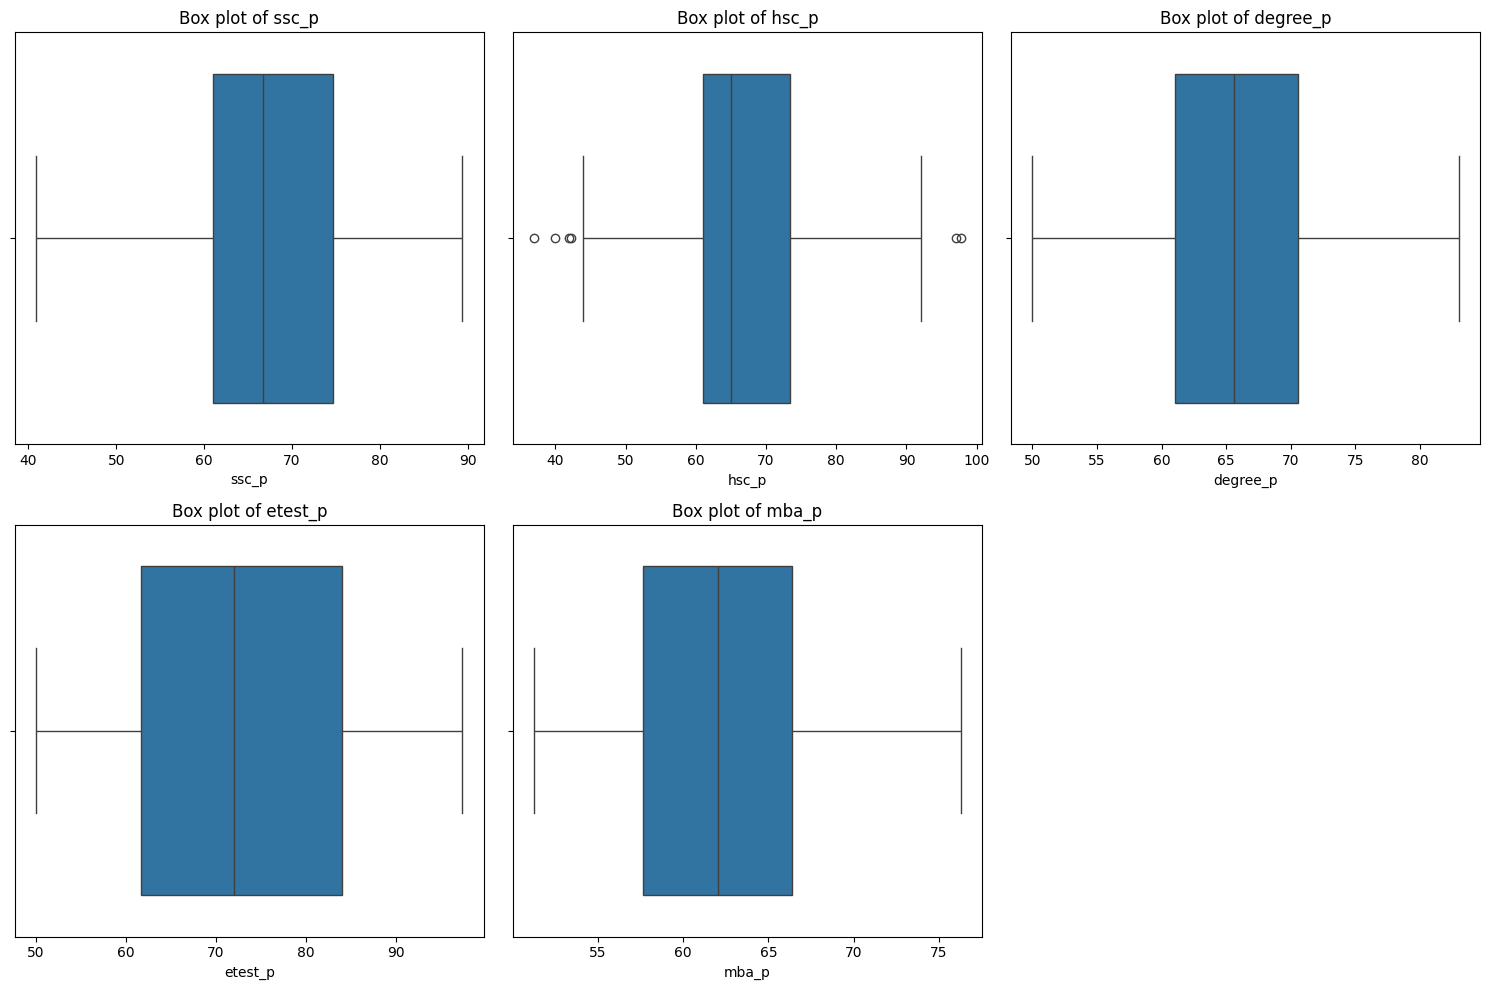


Box plots display the distribution of each numerical feature and highlight potential outliers (points outside the 'whiskers').
Further investigation using statistical methods like IQR or Z-score for outlier detection and handling might be beneficial if severe outliers are present and impacting performance.


In [24]:
print("\n--- Overfitting Check ---")

# Make predictions on the training set
y_train_pred = model.predict(X_train)
y_train_pred_proba = model.predict_proba(X_train)[:, 1]

# Calculate metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, pos_label='Placed')
train_recall = recall_score(y_train, y_train_pred, pos_label='Placed')
train_fpr, train_tpr, _ = roc_curve(y_train, y_train_pred_proba, pos_label='Placed')
train_auc = auc(train_fpr, train_tpr)

print(f"Training Set Metrics:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall: {train_recall:.4f}")
print(f"  AUC: {train_auc:.4f}")

print(f"\nDevelopment Set Metrics (re-calculated for comparison):")
print(f"  Accuracy: {accuracy:.4f}") # 'accuracy' from previous cell
print(f"  Precision: {precision:.4f}") # 'precision' from previous cell
print(f"  Recall: {recall:.4f}") # 'recall' from previous cell
# 'disp_roc.roc_auc' from previous cell
print(f"  AUC: {disp_roc.roc_auc:.4f}")

print("\nComparison: If training metrics are significantly higher than development metrics, the model might be overfitting.")

print("\n--- Outlier Analysis (Visualization) ---")

# Select numerical features for outlier visualization
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(x=X_train[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

print("\nBox plots display the distribution of each numerical feature and highlight potential outliers (points outside the 'whiskers').")
print("Further investigation using statistical methods like IQR or Z-score for outlier detection and handling might be beneficial if severe outliers are present and impacting performance.")